In [3]:
import xarray as xr
import pandas as pd
from scipy import stats
import numpy as np
from cartopy import crs as ccrs, feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from metpy.units import units
import glob,os
from scipy import stats
from scipy.stats import t
from scipy.stats import ttest_ind
import matplotlib.colors as mcolors
%run ../functions/Transfer_longitude.ipynb
%run ../functions/Yearly_mean.ipynb
%run ../functions/Seasonal_means.ipynb
%run ../functions/Weighted_monthly_mean.ipynb
%run ../functions/mask_land_ocean.ipynb
%run ../functions/Moving_mean.ipynb

ERROR 1: PROJ: proj_create_from_database: Open of /knight/anaconda_aug22/envs/aug22_env/share/proj failed


## Read the data

In [4]:
diri='/zhoulab_rit/lzhuo/data/Modelling/Clim/'
filename='TREFHT.nc'
fi=xr.open_dataset(diri+filename)
t2m=fi.TREFHT
## Transfer the longitude
T2m=central180_to_0(t2m)
## Redefine the time coordinate
T2m['time']=pd.date_range('1979-01-01','1999-12-01',freq='MS')
## Calculate the boreal warm season mean
T2m_ctl=weighted_mean_multiple(T2m)
# ## Calculate the mean over the Sahara
# T2m_SD_ctl=T2m_JN.sel(lat=slice(20,30),lon=slice(-10,30)).mean(dim=['lat','lon'])

diri='/zhoulab_rit/lzhuo/data/Modelling/Ind_season_SST/'
filename='TREFHT.nc'
fi=xr.open_dataset(diri+filename)
t2m=fi.TREFHT
## Transfer the longitude
T2m=central180_to_0(t2m)
## Redefine the time coordinate
T2m['time']=pd.date_range('1979-01-01','1999-12-01',freq='MS')
## Calculate the boreal warm season mean
T2m_Ind=weighted_mean_multiple(T2m)

diri='/zhoulab_rit/lzhuo/data/Modelling/Med_season_SST/'
filename='TREFHT.nc'
fi=xr.open_dataset(diri+filename)
t2m=fi.TREFHT
## Transfer the longitude
T2m=central180_to_0(t2m)
## Redefine the time coordinate
T2m['time']=pd.date_range('1979-01-01','1999-12-01',freq='MS')
## Calculate the boreal warm season mean
T2m_Med=weighted_mean_multiple(T2m)

diri='/zhoulab_rit/lzhuo/data/Modelling/Car_season_SST/'
# diri='/zhoulab_rit/lzhuo/data/Modelling/Car_season_SST_new_5/'
filename='TREFHT.nc'
fi=xr.open_dataset(diri+filename)
t2m=fi.TREFHT
## Transfer the longitude
T2m=central180_to_0(t2m)
## Redefine the time coordinate
T2m['time']=pd.date_range('1979-01-01','1999-12-01',freq='MS')
## Calculate the boreal warm season mean
T2m_Car=weighted_mean_multiple(T2m)

diri='/zhoulab_rit/lzhuo/data/Modelling/Atlantic_season_SST_1/'
filename='TREFHT.nc'
fi=xr.open_dataset(diri+filename)
t2m=fi.TREFHT
## Transfer the longitude
T2m=central180_to_0(t2m)
## Redefine the time coordinate
T2m['time']=pd.date_range('1979-01-01','1999-12-01',freq='MS')
## Calculate the boreal warm season mean
T2m_Atl=weighted_mean_multiple(T2m)

diri='/zhoulab_rit/lzhuo/data/Modelling/Full_season_SST/'
filename='TREFHT.nc'
fi=xr.open_dataset(diri+filename)
t2m=fi.TREFHT
## Transfer the longitude
T2m=central180_to_0(t2m)
## Redefine the time coordinate
T2m['time']=pd.date_range('1979-01-01','1999-12-01',freq='MS')
## Calculate the boreal warm season mean
T2m_Full=weighted_mean_multiple(T2m)

## Calculate the pvalue based on student t test

In [6]:
def mean_t_test(var2,var1):
    longitude =var2.lon
    latitude  =var2.lat
    # Create two new dataarrays 
    data=np.zeros(shape=(len(latitude),len(longitude)))
    pv = xr.DataArray(data, coords=[latitude, longitude], dims=["latitude", "longitude"])
    # Calculate the trend and pvalue
#     x     = var2.year
    for i in range(0,len(longitude)):
        for j in range(0,len(latitude)):
            y         = var2[:,j,i]
            x         = var1[:,j,i]
            res       = ttest_ind(x, y)
            pv[j,i]   = res.pvalue
    return pv

In [7]:
pvalue_Med=mean_t_test(T2m_Med,T2m_ctl)
pvalue_Car=mean_t_test(T2m_Car,T2m_ctl)
pvalue_Ind=mean_t_test(T2m_Ind,T2m_ctl)
pvalue_Atl=mean_t_test(T2m_Atl,T2m_ctl)
pvalue_Full=mean_t_test(T2m_Full,T2m_ctl)

In [19]:
def plot_t2m_diff(ax,phi,ps):
    fontsize=12
    proj_data = ccrs.PlateCarree() # Our data is lat-lon; thus its native projection is Plate Carree.
    res = '50m'
#     lonE=50
#     lonW=-30
#     latS=10
#     latN=50
    lonE=40
    lonW=-20
    latS=10
    latN=40
    ax.set_extent([lonW,lonE,latS,latN],crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale(res),linewidth=0.5)
    ax.set_xticks([-20, -10,0,10, 20, 30,40], crs=ccrs.PlateCarree())
    ax.set_yticks([20,30], crs=ccrs.PlateCarree())
    lats=phi.lat
    lons=phi.lon
    
    bounds = np.array([-5,-4.5,-4,-3.5,-3,-2.5,-2,-1.5,-1,-0.5,0.5,1,1.5,2,2.5,3,3.5,4,4.5,5])
    N = len(bounds) - 1

#     base = plt.cm.get_cmap("bwr", N)
#     colors = base(np.arange(N))
#     # 找到 [-2,2] 对应的 bin
#     for v in [-2, -1, 0, 1]:
#         i = np.where(bounds[:-1] == v)[0][0]
#         colors[i] = [1, 1, 1, 1]   # 白色

    # 1) 先做一个离散版 bwr（每个 bin 一个颜色）
    base = plt.cm.get_cmap("seismic", N)
    colors = base(np.arange(N))

    # 2) 把 [-1,0] 和 [0,1] 这两个 bin 改成白色
    #    bin i 对应 [bounds[i], bounds[i+1]]
    i1 = np.where(bounds[:-1] == -0.5)[0][0]  # [-1,0]
#     i2 = np.where(bounds[:-1] ==  0)[0][0]  # [0,1]
    colors[i1] = [1, 1, 1, 1]

    # 2) 把 [-1,0] 和 [0,1] 这两个 bin 改成白色
#     #    bin i 对应 [bounds[i], bounds[i+1]]
#     i1 = np.where(bounds[:-1] == -2)[0][0]  # [-1,0]
#     i2 = np.where(bounds[:-1] ==  2)[0][0]  # [0,1]
#     colors[i1] = [1, 1, 1, 1]
#     colors[i2] = [1, 1, 1, 1]
    
#     for v in [-2, -1, 0, 1]:
#         i = np.where(bounds[:-1] == v)[0][0]
#         colors[i] = [1, 1, 1, 1]   # 白色

    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

#     cmap=colorbar('WhiteBlueGreenYellowRed')
#     minVal = -5
#     maxVal = 5+0.5
#     cint = 0.5
#     intervals = np.arange(minVal, maxVal, cint)
    CF = ax.contourf(lons,lats,phi,bounds,transform=proj_data,norm=norm,
                 cmap=cmap,extend='both')
#     lines = ax.contour(lons,lats,phi,levels=[5],colors='white', linewidths=1.5,transform=proj_data)
                 #cmap=plt.get_cmap('bwr')
#     cbar=plt.colorbar(CF,ax=ax,orientation="horizontal",aspect=50)
#     cbar.ax.tick_params(axis="x",labelsize=fontsize,pad=1)
#     color_list=['blue','blue','blue','red','red','red']
#     lines = ax.contour(lons,lats,phi_line,levels=line_intervals,colors='black', linewidths=1.5,transform=proj_data)
#     ax.clabel(lines, lines.levels,fontsize=12, fmt='%3.2f', inline=True)
#     Q = ax.quiver(lons[::4], lats[::4], u[::4,::4], v[::4,::4], color='black',units='xy',width=1,
#                   scale=0.05,scale_units='xy',transform=proj_data)
    # plot the dots using scatter
    nx, ny = np.meshgrid(ps[::2,::2].longitude, ps[::2,::2].latitude)
    area = np.where(ps[::2,::2] < 0.01 )
    sig1 = ax.scatter(nx[area], ny[area],  s = 6, c = 'black', transform = ccrs.PlateCarree())
    ax.xaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    ax.yaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    lon_formatter = LongitudeFormatter()
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    return ax,CF

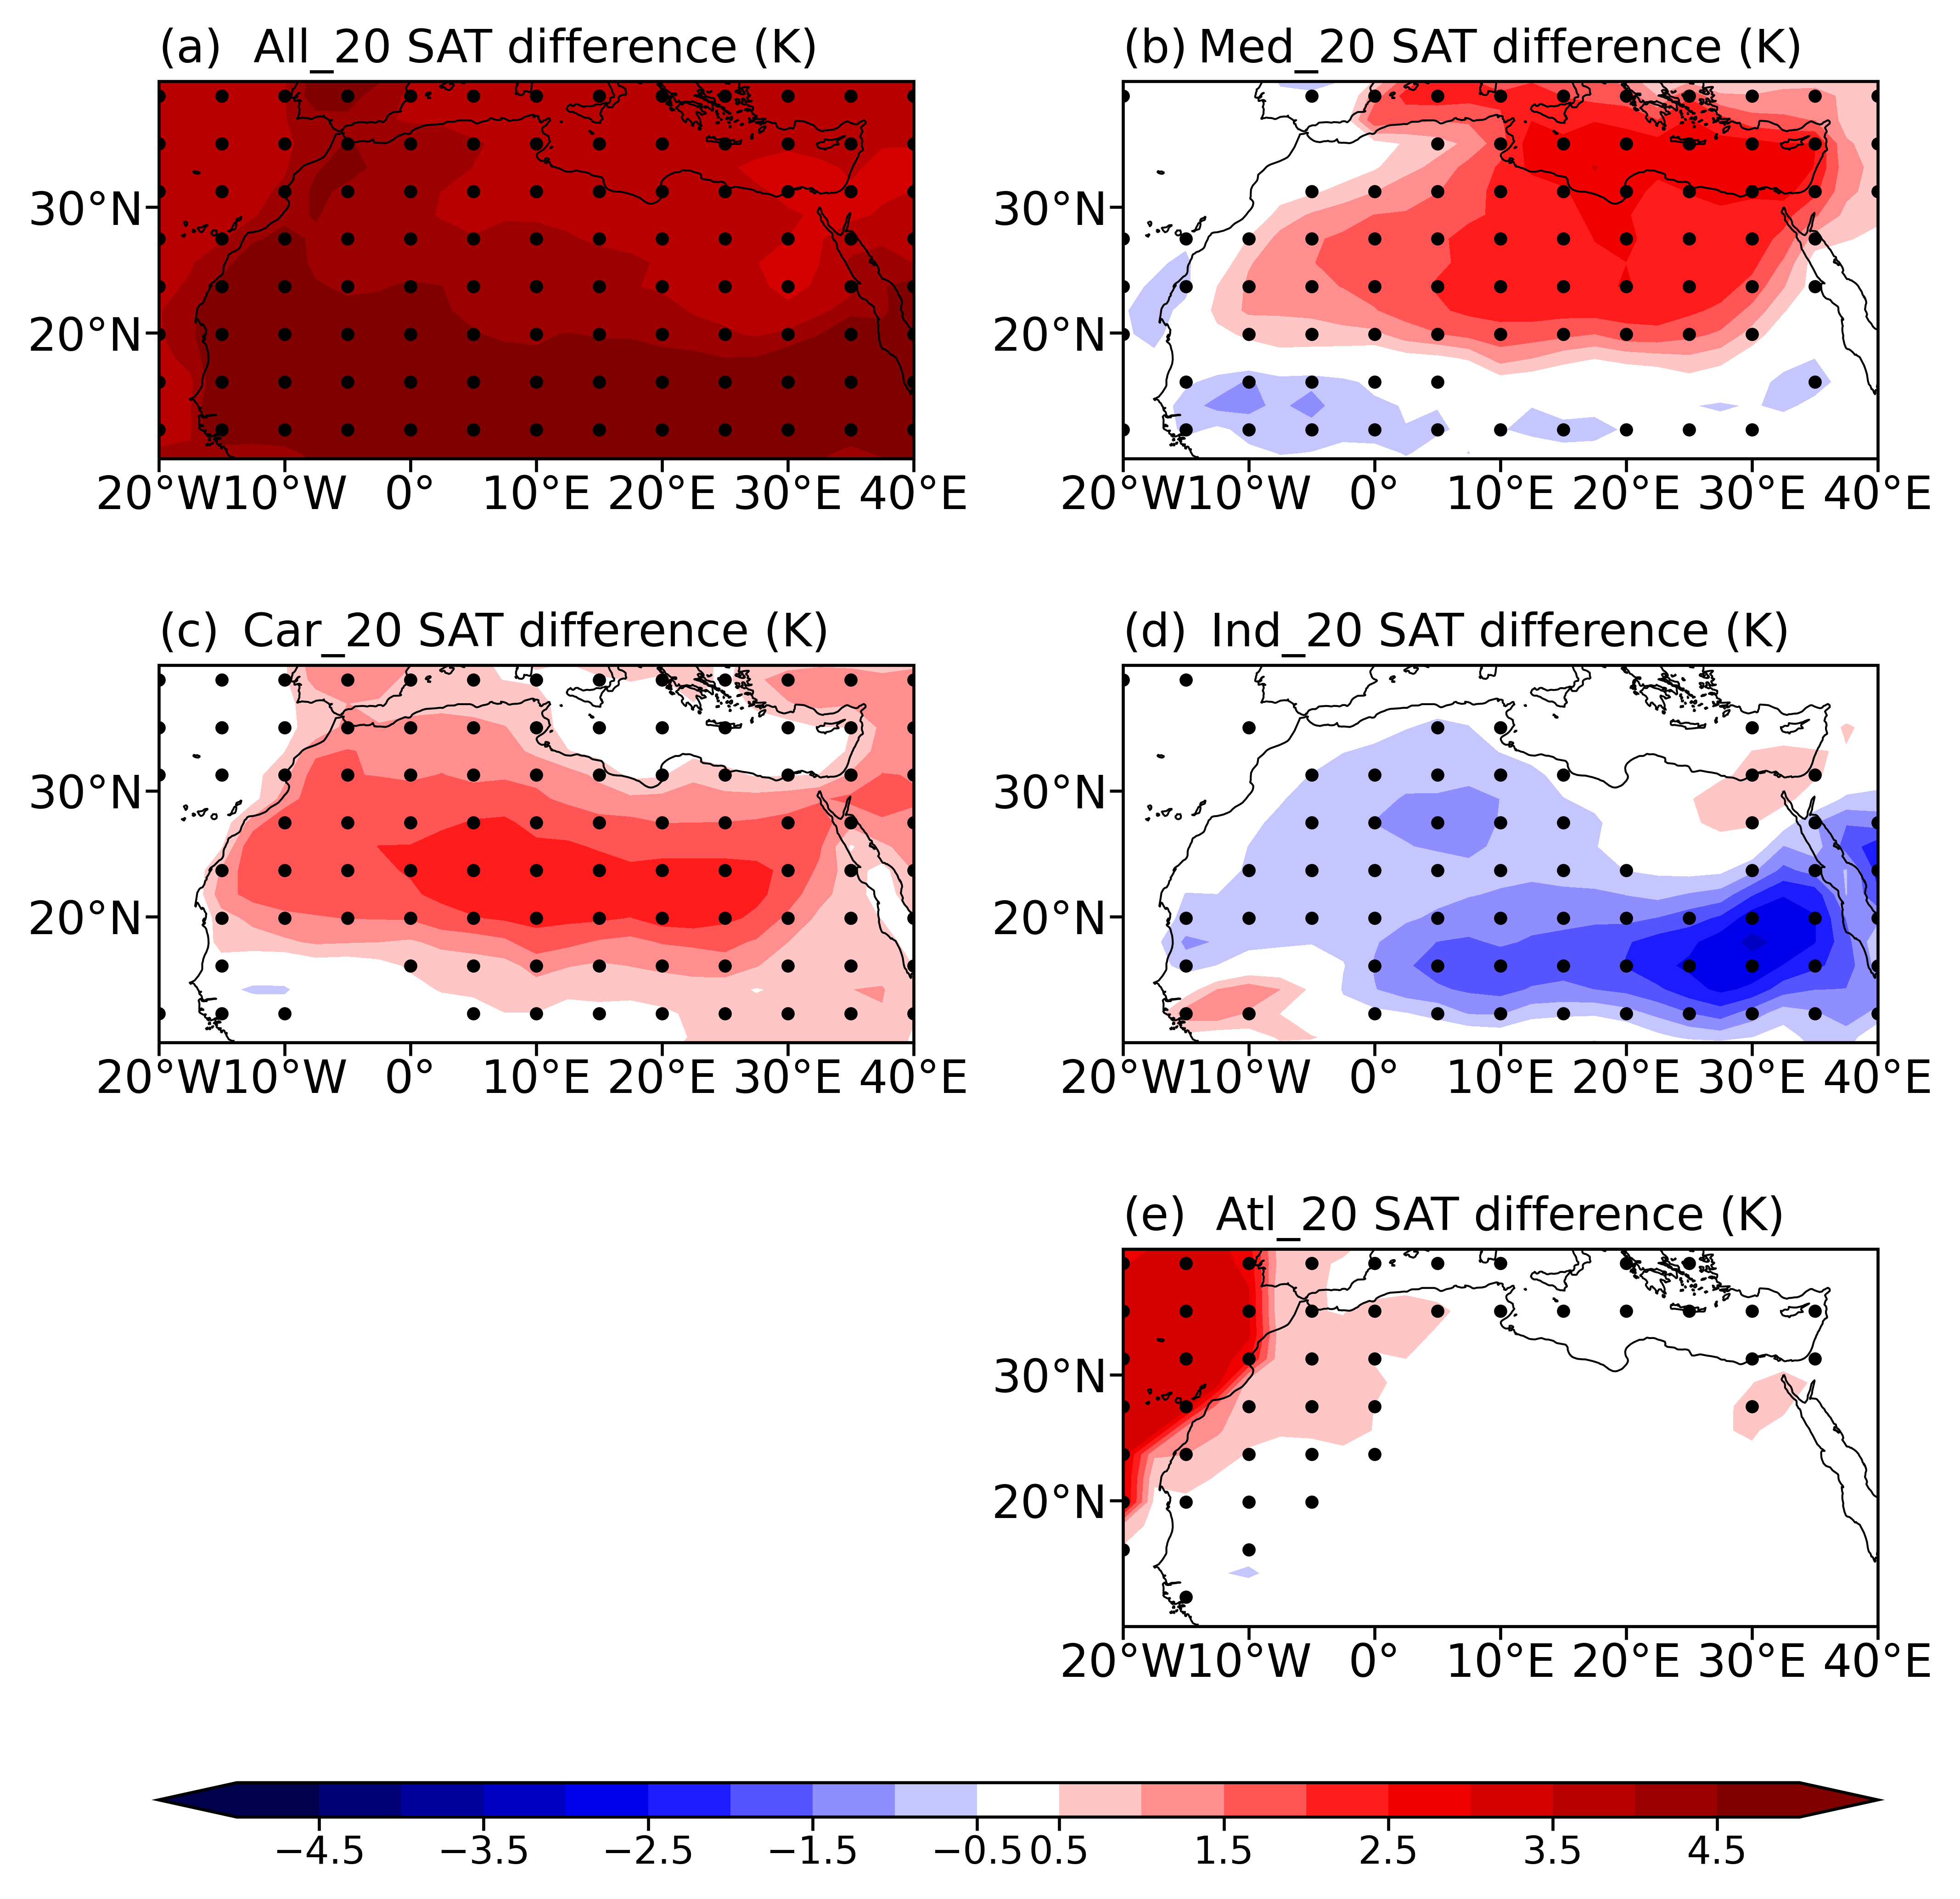

In [25]:
fig = plt.figure(figsize=(7, 7),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=2,
                        nrows=3)
ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())
diff   =T2m_Full.mean(dim='year')-T2m_ctl.mean(dim='year')
var    =mpcalc.smooth_n_point(diff, 9, 1)
ps     =pvalue_Full
ax1,CF =plot_t2m_diff(ax,diff,ps)
fontsize=12
pad=5
ax1.set_title('All_20 SAT difference (K)',fontsize=fontsize,pad=pad)
ax1.set_title('(a)',fontsize=fontsize,pad=pad,loc='left')

ax = fig.add_subplot(grid[0, 1],projection=ccrs.PlateCarree())
diff   =T2m_Med.mean(dim='year')-T2m_ctl.mean(dim='year')
var    =mpcalc.smooth_n_point(diff, 9, 1)
ps     =pvalue_Med
ax2,CF =plot_t2m_diff(ax,diff,ps)

ax2.set_title('Med_20 SAT difference (K)',fontsize=fontsize,pad=pad)
ax2.set_title('(b)',fontsize=fontsize,pad=pad,loc='left')

ax = fig.add_subplot(grid[1, 0],projection=ccrs.PlateCarree())
diff   =T2m_Car.mean(dim='year')-T2m_ctl.mean(dim='year')
var    =mpcalc.smooth_n_point(diff, 9, 1)
ps     =pvalue_Car
ax3,CF =plot_t2m_diff(ax,diff,ps)

ax3.set_title('Car_20 SAT difference (K)',fontsize=fontsize,pad=pad)
ax3.set_title('(c)',fontsize=fontsize,pad=pad,loc='left')

ax = fig.add_subplot(grid[1, 1],projection=ccrs.PlateCarree())
diff   =T2m_Ind.mean(dim='year')-T2m_ctl.mean(dim='year')
var    =mpcalc.smooth_n_point(diff, 9, 1)
ps     =pvalue_Ind
ax4,CF =plot_t2m_diff(ax,diff,ps)

ax4.set_title('Ind_20 SAT difference (K)',fontsize=fontsize,pad=pad)
ax4.set_title('(d)',fontsize=fontsize,pad=pad,loc='left')

ax = fig.add_subplot(grid[2, 1],projection=ccrs.PlateCarree())
diff   =T2m_Atl.mean(dim='year')-T2m_ctl.mean(dim='year')
var    =mpcalc.smooth_n_point(diff, 9, 1)
ps     =pvalue_Atl
ax5,CF =plot_t2m_diff(ax,diff,ps)

ax5.set_title('Atl_20 SAT difference (K)',fontsize=fontsize,pad=pad)
ax5.set_title('(e)',fontsize=fontsize,pad=pad,loc='left')

cbar=plt.colorbar(CF,ax=[ax1,ax2,ax3,ax4,ax5],orientation="horizontal",aspect=50)
cbar.ax.tick_params(axis="x",labelsize=10,pad=1)

bounds = np.array([-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5])
cbar.set_ticks(bounds)